In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('/content/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
print("Total number of titles:", len(df))

df.info()
df.isnull().sum()

Total number of titles: 8807
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [20]:
df = df.dropna(subset=['type', 'country', 'rating'])

df.fillna("Unknown", inplace=True)

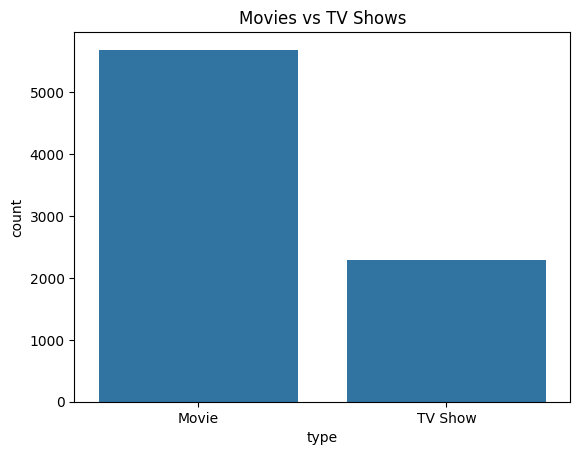

In [21]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

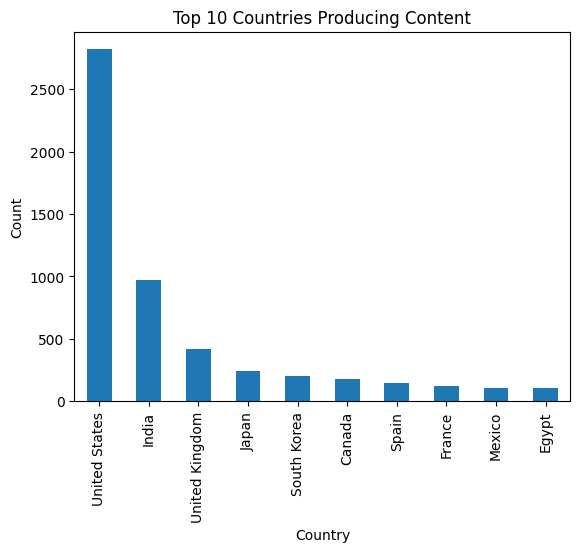

In [22]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

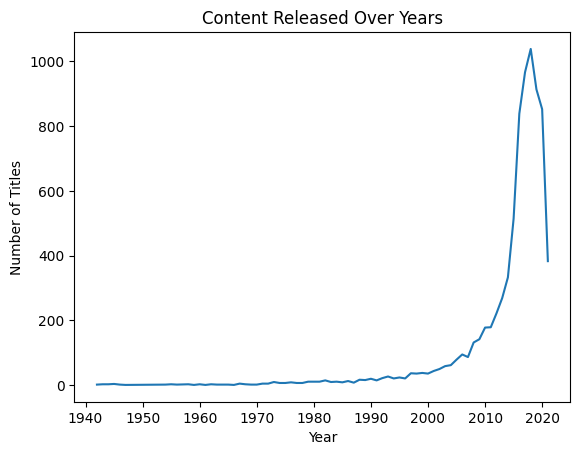

In [23]:
df['release_year'].value_counts().sort_index().plot()

plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

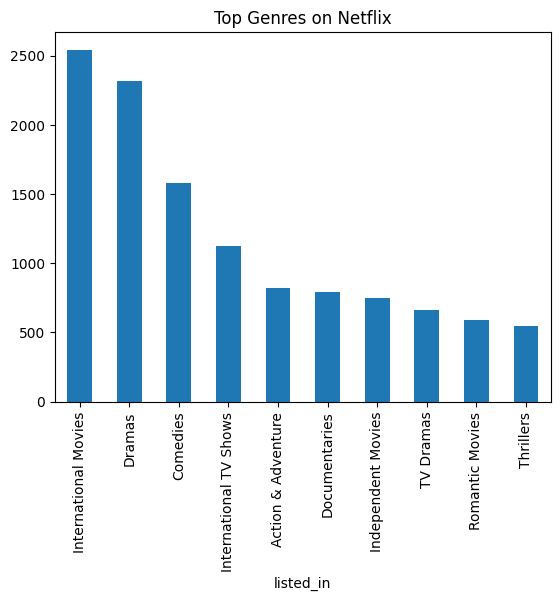

In [24]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.show()

In [25]:
def recommend(genre):
    return df[df['listed_in'].str.contains(genre, case=False)][['title', 'listed_in']].head(5)

recommend("Comedy")

,title,listed_in
278,Lokillo: Nothing's the Same,Stand-Up Comedy
359,The Original Kings of Comedy,Stand-Up Comedy
511,Chelsea,"Stand-Up Comedy & Talk Shows, TV Comedies"
744,Locombianos,"International TV Shows, Spanish-Language TV Sh..."
766,Alan Saldaña: Locked Up,Stand-Up Comedy


In [26]:
recommend("Drama")
recommend("Action")

,title,listed_in
21,Resurrection: Ertugrul,"International TV Shows, TV Action & Adventure,..."
38,Birth of the Dragon,"Action & Adventure, Dramas"
41,Jaws,"Action & Adventure, Classic Movies, Dramas"
43,Jaws 3,"Action & Adventure, Horror Movies, Thrillers"
44,Jaws: The Revenge,"Action & Adventure, Horror Movies, Thrillers"


In [27]:
print("\nMost common rating:")
print(df['rating'].value_counts().head())


Most common rating:
rating
TV-MA    2931
TV-14    1930
R         788
TV-PG     773
PG-13     482
Name: count, dtype: int64


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2423/856290700.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)


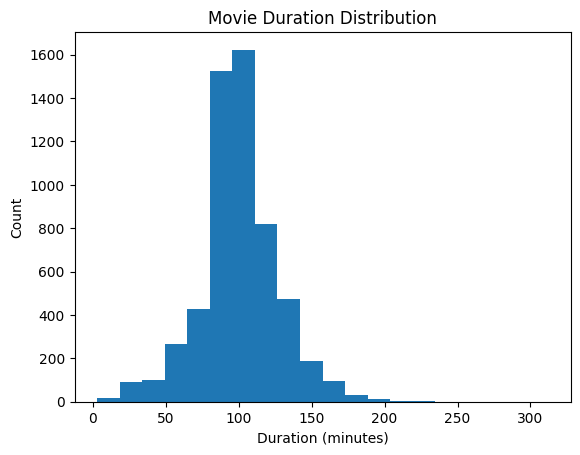

In [28]:
# Convert duration to numeric (for movies only)

df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)

movies = df[df['type'] == 'Movie']

plt.hist(movies['duration_int'].dropna(), bins=20)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

In [29]:
# Improved recommendation: genre + country

def recommend_advanced(genre, country):
    result = df[
        (df['listed_in'].str.contains(genre, case=False)) &
        (df['country'].str.contains(country, case=False))
    ][['title', 'country', 'listed_in']]

    return result.head(5)

recommend_advanced("Drama", "India")

,title,country,listed_in
50,Dharmakshetra,India,"International TV Shows, TV Dramas, TV Sci-Fi &..."
69,Stories by Rabindranath Tagore,India,"International TV Shows, TV Dramas"
105,Angamaly Diaries,India,"Action & Adventure, Comedies, Dramas"
114,Anjaam,India,"Dramas, International Movies, Thrillers"
116,Dhanak,India,"Comedies, Dramas, Independent Movies"


In [30]:
print("\n--- Key Insights ---")

print("1. Movies are more common than TV Shows on Netflix.")

print("2. Content production has increased significantly in recent years.")

print("3. Drama and Comedy are the most dominant genres.")

print("4. Most content comes from a few major countries.")

print("5. Movie duration mostly falls between 80–120 minutes.")


--- Key Insights ---
1. Movies are more common than TV Shows on Netflix.
2. Content production has increased significantly in recent years.
3. Drama and Comedy are the most dominant genres.
4. Most content comes from a few major countries.
5. Movie duration mostly falls between 80–120 minutes.
